In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data from your CSVs

def load_yfinance_csv(path, asset_name):
    df = pd.read_csv(path)
    df = df.iloc[2:].copy()
    df.rename(columns={"Price": "Date"}, inplace=True)
    df = df[["Date", "Close"]].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df[asset_name] = pd.to_numeric(df["Close"], errors="coerce")
    df = df[["Date", asset_name]].dropna()
    return df


# 1. Load KO and PEP
ko = load_yfinance_csv("KO_daily.csv", "KO")
pep = load_yfinance_csv("PEP_daily.csv", "PEP")

df = pd.merge(ko, pep, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)

In [3]:
# Compute returns and log prices

df["KO"] = pd.to_numeric(df["KO"], errors="coerce")
df["PEP"] = pd.to_numeric(df["PEP"], errors="coerce")

df = df.dropna(subset=["KO", "PEP"])
df = df[(df["KO"] > 0) & (df["PEP"] > 0)].copy()
df = df.sort_values("Date").reset_index(drop=True)

df["KO_ret"] = df["KO"].pct_change()
df["PEP_ret"] = df["PEP"].pct_change()

df["log_KO"] = np.log(df["KO"])
df["log_PEP"] = np.log(df["PEP"])

training_set = df[(df["Date"] >= "2000-01-01") & (df["Date"] < "2020-01-01")].copy().reset_index(drop=True)
test_set = df[df["Date"] >= "2020-01-01"].copy().reset_index(drop=True)

In [4]:
# Hyperparameter testing for lookback

def run_backtest_for_lookback(original_df, lookback, entry_z=2.0, exit_z=0.5):
    """
    Runs the KO-PEP pairs strategy for one lookback value.
    Returns performance metrics and the full backtest dataframe.
    """

    df = original_df.copy()

    df["beta"] = np.nan
    df["spread"] = np.nan
    df["zscore"] = np.nan

    # Estimate rolling beta, spread, and z-score
    for i in range(lookback, len(df)):
        train = df.iloc[i - lookback:i]

        x = train["log_KO"].values
        y = train["log_PEP"].values

        beta = np.polyfit(x, y, 1)[0]
        df.loc[i, "beta"] = beta

        train_spread = train["log_PEP"] - beta * train["log_KO"]
        mu = train_spread.mean()
        sigma = train_spread.std()

        current_spread = df.loc[i, "log_PEP"] - beta * df.loc[i, "log_KO"]

        df.loc[i, "spread"] = current_spread
        df.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma

    # Trading position
    df["position"] = 0.0
    current_pos = 0

    for i in range(lookback, len(df)):
        z = df.loc[i, "zscore"]

        if current_pos == 0:
            if z > entry_z:
                current_pos = -1  # short spread: short PEP, long KO
            elif z < -entry_z:
                current_pos = 1  # long spread: long PEP, short KO

        elif current_pos == 1:
            if z > -exit_z:
                current_pos = 0

        elif current_pos == -1:
            if z < exit_z:
                current_pos = 0

        df.loc[i, "position"] = current_pos

    # Strategy returns
    df["beta_ffill"] = df["beta"].ffill()
    df["spread_ret"] = df["PEP_ret"] - df["beta_ffill"] * df["KO_ret"]

    df["position_lag"] = df["position"].shift(1).fillna(0)
    df["strategy_ret"] = df["position_lag"] * df["spread_ret"]
    df["strategy_ret"] = df["strategy_ret"].fillna(0)

    df["equity_curve"] = (1 + df["strategy_ret"]).cumprod()

    # Metrics
    mean_ret = df["strategy_ret"].mean()
    std_ret = df["strategy_ret"].std()

    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret
    total_return = df["equity_curve"].iloc[-1] - 1

    rolling_max = df["equity_curve"].cummax()
    drawdown = df["equity_curve"] / rolling_max - 1
    max_drawdown = drawdown.min()

    num_trades = (df["position"].diff().abs() > 0).sum()

    return {
        "lookback": lookback,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "num_trades": num_trades,
        "final_equity": df["equity_curve"].iloc[-1],
        "backtest_df": df
    }

In [5]:
results = []

# test for lookback values from a quarter of a trading year to 2
for lb in range(63, 504, 2):
    result = run_backtest_for_lookback(training_set, lookback=lb, entry_z=2.0, exit_z=0.5)

    results.append({
        "lookback": result["lookback"],
        "sharpe": result["sharpe"],
        "total_return": result["total_return"],
        "max_drawdown": result["max_drawdown"],
        "num_trades": result["num_trades"],
        "final_equity": result["final_equity"]
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("sharpe", ascending=False)

results_df

,lookback,sharpe,total_return,max_drawdown,num_trades,final_equity
7,77,0.589593,2.164988,-0.238168,228,3.164988
4,71,0.588305,2.118772,-0.220033,236,3.118772
2,67,0.577128,2.096091,-0.223944,248,3.096091
26,115,0.576879,2.295905,-0.277507,172,3.295905
27,117,0.564550,2.144101,-0.277757,170,3.144101
...,...,...,...,...,...,...
160,383,0.182331,0.314994,-0.266074,48,1.314994
63,189,0.175432,0.298262,-0.322156,102,1.298262
56,175,0.167166,0.278964,-0.319505,104,1.278964
58,179,0.161880,0.262091,-0.318371,102,1.262091


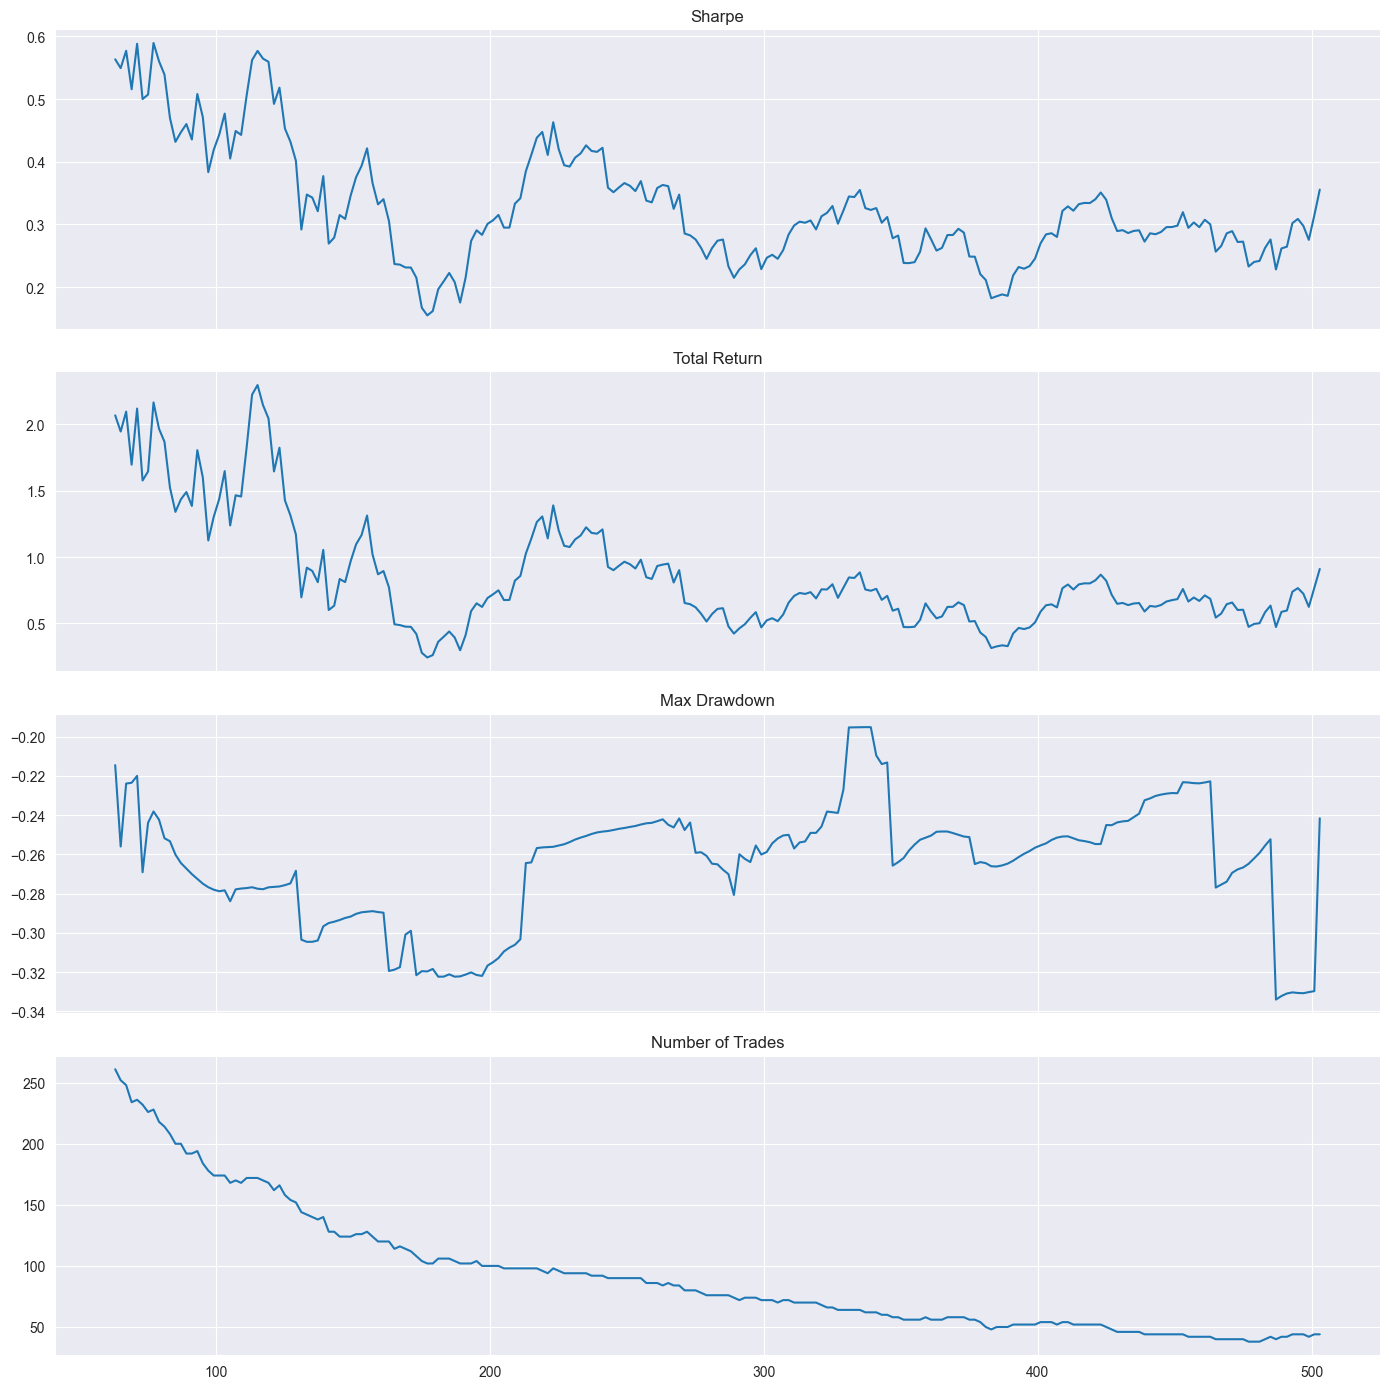

In [7]:
results_df = results_df.sort_values("lookback", ascending=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(results_df["lookback"], results_df["sharpe"], label="Sharpe")
axes[0].set_title("Sharpe")

axes[1].plot(results_df["lookback"], results_df["total_return"], label="Total Return")
axes[1].set_title("Total Return")

axes[2].plot(results_df["lookback"], results_df["max_drawdown"], label="Max Drawdown")
axes[2].set_title("Max Drawdown")

axes[3].plot(results_df["lookback"], results_df["num_trades"], label="Number of Trades")
axes[3].set_title("Number of Trades")

plt.tight_layout()
plt.show()

In [8]:
results = []

# test for lookback values from a quarter of a trading year to 2
for lb in range(65, 85, 1):
    result = run_backtest_for_lookback(training_set, lookback=lb, entry_z=2.0, exit_z=0.5)

    results.append({
        "lookback": result["lookback"],
        "sharpe": result["sharpe"],
        "total_return": result["total_return"],
        "max_drawdown": result["max_drawdown"],
        "num_trades": result["num_trades"],
        "final_equity": result["final_equity"]
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("sharpe", ascending=False)

results_df

,lookback,sharpe,total_return,max_drawdown,num_trades,final_equity
13,78,0.606905,2.241356,-0.240089,222,3.241356
12,77,0.589593,2.164988,-0.238168,228,3.164988
6,71,0.588305,2.118772,-0.220033,236,3.118772
2,67,0.577128,2.096091,-0.223944,248,3.096091
11,76,0.569327,2.018611,-0.235994,226,3.018611
14,79,0.560455,1.966668,-0.242329,218,2.966668
15,80,0.559021,1.992060,-0.255959,218,2.992060
5,70,0.553973,1.909534,-0.217121,236,2.909534
1,66,0.551113,1.928683,-0.245555,252,2.928683
3,68,0.550421,1.914507,-0.238603,236,2.914507


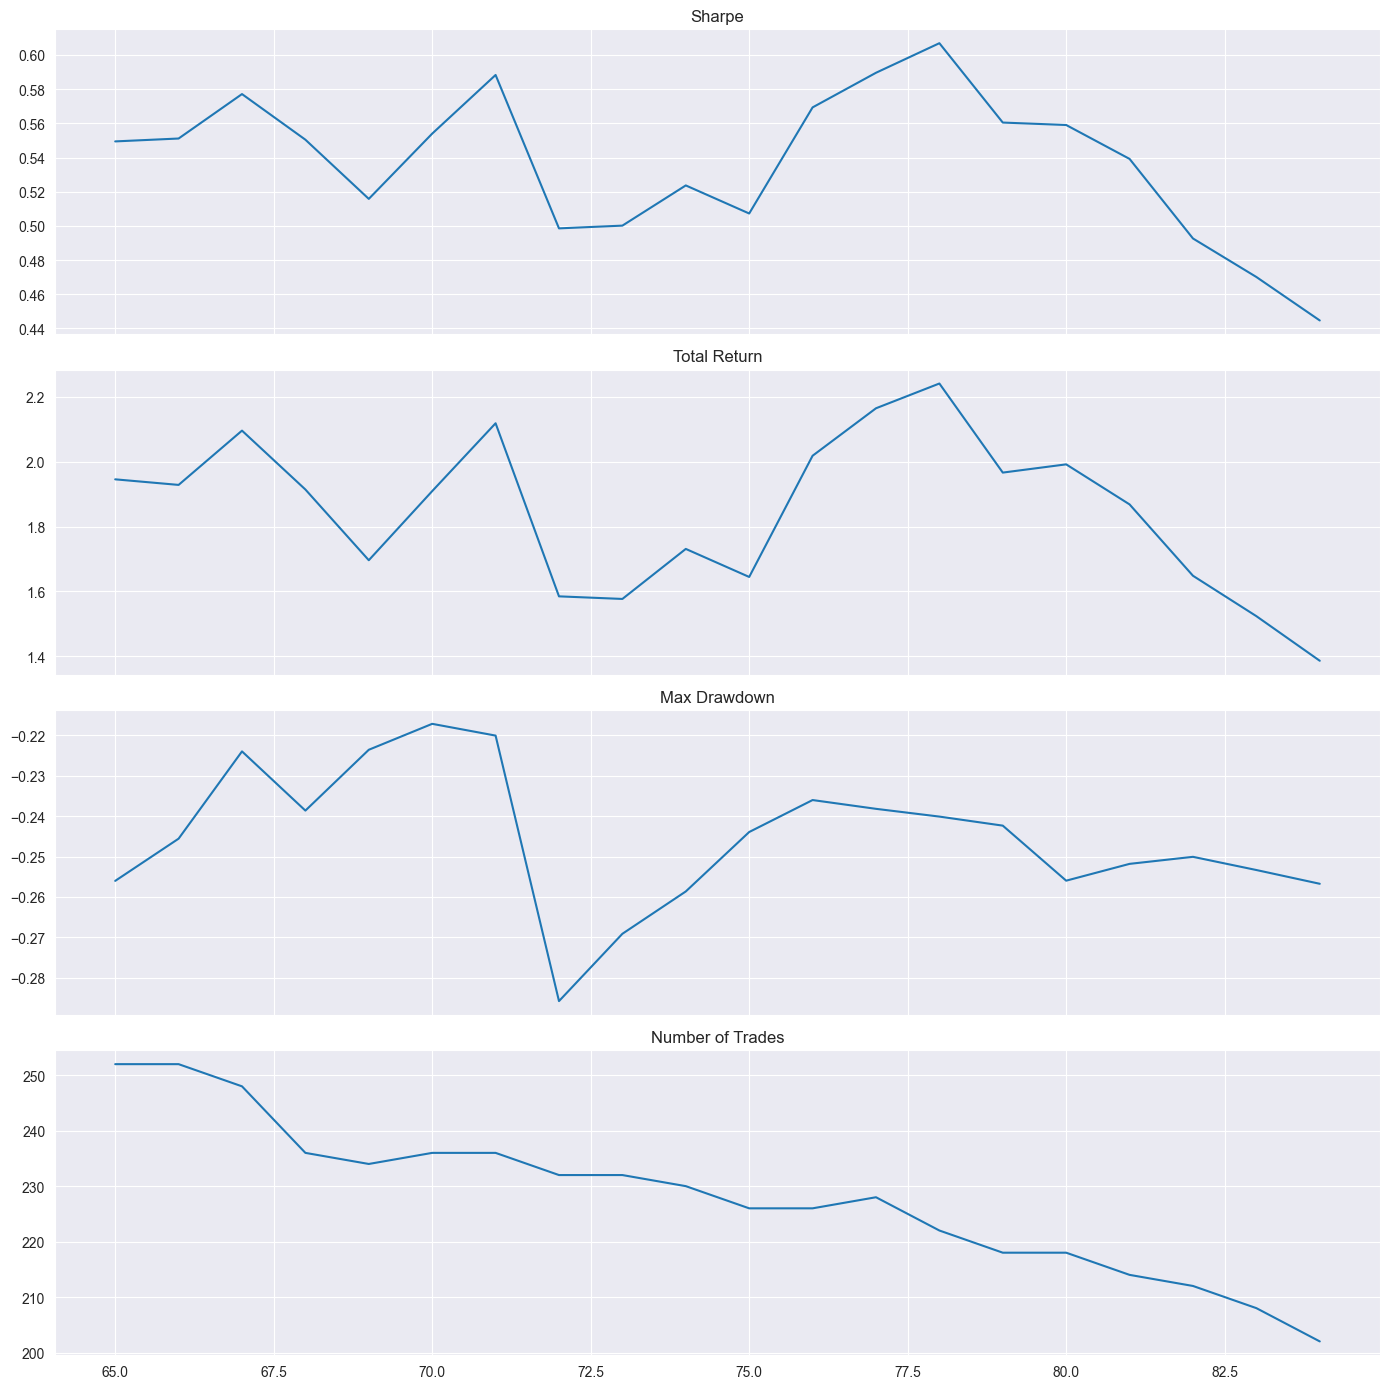

In [9]:
results_df = results_df.sort_values("lookback", ascending=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(results_df["lookback"], results_df["sharpe"], label="Sharpe")
axes[0].set_title("Sharpe")

axes[1].plot(results_df["lookback"], results_df["total_return"], label="Total Return")
axes[1].set_title("Total Return")

axes[2].plot(results_df["lookback"], results_df["max_drawdown"], label="Max Drawdown")
axes[2].set_title("Max Drawdown")

axes[3].plot(results_df["lookback"], results_df["num_trades"], label="Number of Trades")
axes[3].set_title("Number of Trades")

plt.tight_layout()
plt.show()

Set the lookback to 78 days.

In [11]:
# Hyperparameter testing for entry and exit z-score thresholds

def run_backtest_for_entry_and_exit(original_df, entry_z, exit_z, lookback=78):
    """
    Runs the KO-PEP pairs strategy for entry_z and exit_z values.
    Returns performance metrics and the full backtest dataframe.
    """

    df = original_df.copy()

    df["beta"] = np.nan
    df["spread"] = np.nan
    df["zscore"] = np.nan

    # Estimate rolling beta, spread, and z-score
    for i in range(lookback, len(df)):
        train = df.iloc[i - lookback:i]

        x = train["log_KO"].values
        y = train["log_PEP"].values

        beta = np.polyfit(x, y, 1)[0]
        df.loc[i, "beta"] = beta

        train_spread = train["log_PEP"] - beta * train["log_KO"]
        mu = train_spread.mean()
        sigma = train_spread.std()

        current_spread = df.loc[i, "log_PEP"] - beta * df.loc[i, "log_KO"]

        df.loc[i, "spread"] = current_spread
        df.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma

    # Trading position
    df["position"] = 0.0
    current_pos = 0

    for i in range(lookback, len(df)):
        z = df.loc[i, "zscore"]

        if current_pos == 0:
            if z > entry_z:
                current_pos = -1  # short spread: short PEP, long KO
            elif z < -entry_z:
                current_pos = 1  # long spread: long PEP, short KO

        elif current_pos == 1:
            if z > -exit_z:
                current_pos = 0

        elif current_pos == -1:
            if z < exit_z:
                current_pos = 0

        df.loc[i, "position"] = current_pos

    # Strategy returns
    df["beta_ffill"] = df["beta"].ffill()
    df["spread_ret"] = df["PEP_ret"] - df["beta_ffill"] * df["KO_ret"]

    df["position_lag"] = df["position"].shift(1).fillna(0)
    df["strategy_ret"] = df["position_lag"] * df["spread_ret"]
    df["strategy_ret"] = df["strategy_ret"].fillna(0)

    df["equity_curve"] = (1 + df["strategy_ret"]).cumprod()

    # Metrics
    mean_ret = df["strategy_ret"].mean()
    std_ret = df["strategy_ret"].std()

    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret
    total_return = df["equity_curve"].iloc[-1] - 1

    rolling_max = df["equity_curve"].cummax()
    drawdown = df["equity_curve"] / rolling_max - 1
    max_drawdown = drawdown.min()

    num_trades = (df["position"].diff().abs() > 0).sum()

    return {
        "entry_z": entry_z,
        "exit_z": exit_z,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "num_trades": num_trades,
        "final_equity": df["equity_curve"].iloc[-1],
        "backtest_df": df
    }

In [12]:
results = []

# Test for entry and exit z-values

for entry_z in np.round(np.arange(1.0, 2.0, 0.1), 2):
    for exit_z in np.round(np.arange(0.5, 1.5, 0.1), 2):

        if exit_z >= entry_z:
            continue

        result = run_backtest_for_entry_and_exit(training_set, entry_z=entry_z, exit_z=exit_z)

        results.append({
            "entry_z": entry_z,
            "exit_z": exit_z,
            "sharpe": result["sharpe"],
            "total_return": result["total_return"],
            "max_drawdown": result["max_drawdown"],
            "num_trades": result["num_trades"],
            "final_equity": result["final_equity"]
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("sharpe", ascending=False)

results_df

,entry_z,exit_z,sharpe,total_return,max_drawdown,num_trades,final_equity
30,1.4,0.9,0.746381,3.832296,-0.240850,455,4.832296
49,1.6,0.9,0.694563,3.071188,-0.240089,372,4.071188
39,1.5,0.9,0.689224,3.099675,-0.240089,408,4.099675
4,1.0,0.9,0.686278,3.851884,-0.251353,747,4.851884
33,1.4,1.2,0.676943,2.802908,-0.246347,553,3.802908
...,...,...,...,...,...,...,...
78,1.9,0.8,0.508078,1.601073,-0.249612,258,2.601073
71,1.8,1.1,0.507909,1.443893,-0.240089,322,2.443893
64,1.7,1.4,0.506375,1.358195,-0.240089,416,2.358195
68,1.8,0.8,0.489373,1.539927,-0.247458,278,2.539927


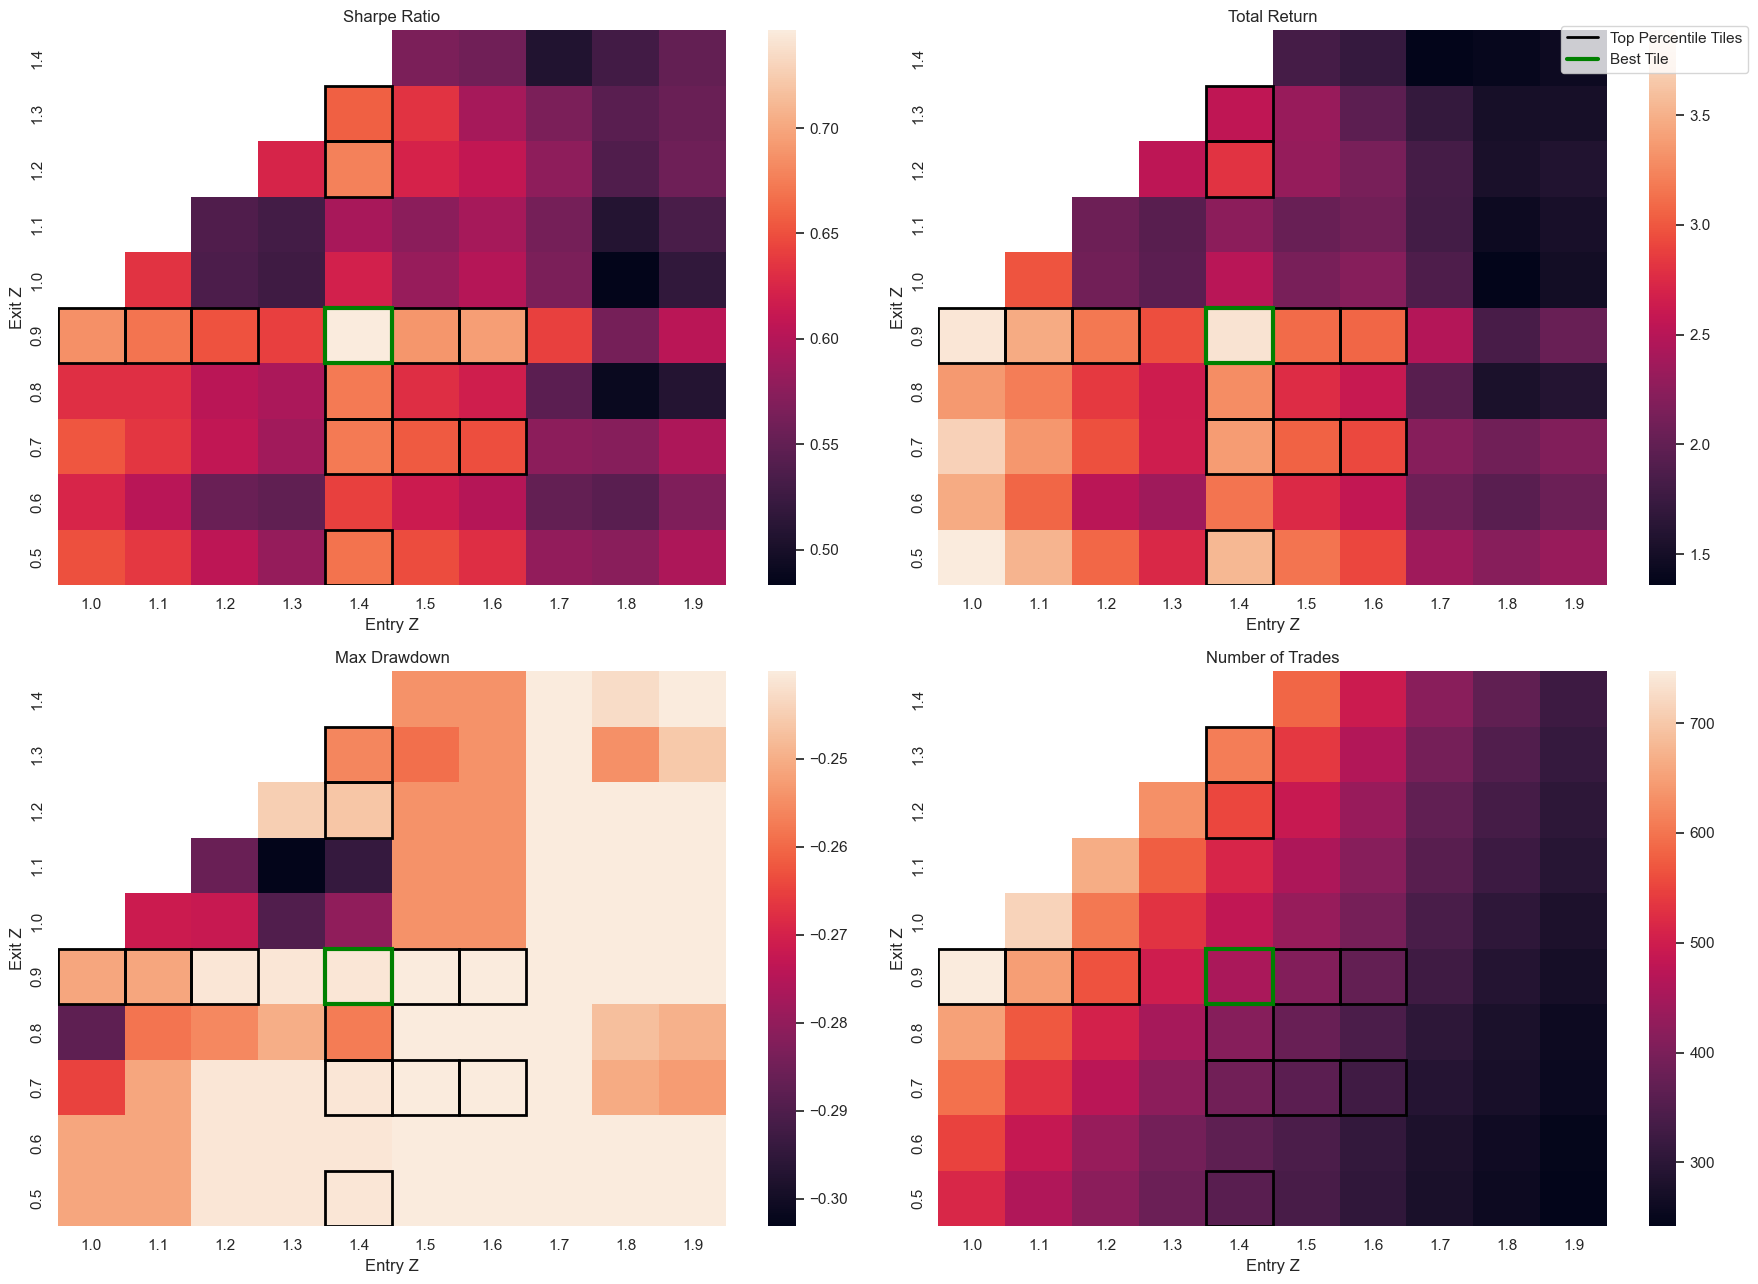

In [13]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

sns.set_theme(style="white")

results_df = results_df.copy()
results_df["risk_score"] = results_df["sharpe"] - 0.5 * results_df["max_drawdown"].abs()

sharpe_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="sharpe")
return_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="total_return")
drawdown_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="max_drawdown")
trades_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="num_trades")
risk_pivot = results_df.pivot(index="exit_z", columns="entry_z", values="risk_score")

sharpe_pivot = sharpe_pivot.sort_index(ascending=False)
return_pivot = return_pivot.sort_index(ascending=False)
drawdown_pivot = drawdown_pivot.sort_index(ascending=False)
trades_pivot = trades_pivot.sort_index(ascending=False)
risk_pivot = risk_pivot.sort_index(ascending=False)

best_sharpe_exit, best_sharpe_entry = sharpe_pivot.stack().idxmax()
best_sharpe_row = sharpe_pivot.index.get_loc(best_sharpe_exit)
best_sharpe_col = sharpe_pivot.columns.get_loc(best_sharpe_entry)

threshold = risk_pivot.stack().quantile(0.85)
eligible_mask = (risk_pivot >= threshold) & (~risk_pivot.isna())

top_percentile_cells = []
for r in range(eligible_mask.shape[0]):
    for c in range(eligible_mask.shape[1]):
        if eligible_mask.iat[r, c]:
            top_percentile_cells.append((r, c))


def add_highlights(ax, best_sharpe_row, best_sharpe_col, top_percentile_cells):
    for r, c in top_percentile_cells:
        rect = Rectangle((c, r), 1, 1, fill=False, edgecolor="black", linewidth=2)
        ax.add_patch(rect)

    rect = Rectangle((best_sharpe_col, best_sharpe_row), 1, 1, fill=False, edgecolor="green", linewidth=3)
    ax.add_patch(rect)


fig, axes = plt.subplots(2, 2, figsize=(18, 13))

sns.heatmap(sharpe_pivot, annot=False, ax=axes[0, 0], cbar=True)
axes[0, 0].set_title("Sharpe Ratio")
axes[0, 0].set_xlabel("Entry Z")
axes[0, 0].set_ylabel("Exit Z")
add_highlights(axes[0, 0], best_sharpe_row, best_sharpe_col, top_percentile_cells)

sns.heatmap(return_pivot, annot=False, ax=axes[0, 1], cbar=True)
axes[0, 1].set_title("Total Return")
axes[0, 1].set_xlabel("Entry Z")
axes[0, 1].set_ylabel("Exit Z")
add_highlights(axes[0, 1], best_sharpe_row, best_sharpe_col, top_percentile_cells)

sns.heatmap(drawdown_pivot, annot=False, ax=axes[1, 0], cbar=True)
axes[1, 0].set_title("Max Drawdown")
axes[1, 0].set_xlabel("Entry Z")
axes[1, 0].set_ylabel("Exit Z")
add_highlights(axes[1, 0], best_sharpe_row, best_sharpe_col, top_percentile_cells)

sns.heatmap(trades_pivot, annot=False, ax=axes[1, 1], cbar=True)
axes[1, 1].set_title("Number of Trades")
axes[1, 1].set_xlabel("Entry Z")
axes[1, 1].set_ylabel("Exit Z")
add_highlights(axes[1, 1], best_sharpe_row, best_sharpe_col, top_percentile_cells)

# Legend
legend_handles = [
    Line2D([0], [0], color="black", lw=2, label="Top Percentile Tiles"),
    Line2D([0], [0], color="green", lw=3, label="Best Tile")
]
fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.show()

Set entry_z to 1.4 and exit_z to 0.9

In [14]:
def run_backtest_for_e_stop(original_df, e_stop, entry_z=1.4, exit_z=0.9, lookback=78):
    """
    Runs the KO-PEP pairs strategy for e_stop values.
    Returns performance metrics and the full backtest dataframe.
    """

    df = original_df.copy()

    df["beta"] = np.nan
    df["spread"] = np.nan
    df["zscore"] = np.nan

    # Estimate rolling beta, spread, and z-score
    for i in range(lookback, len(df)):
        train = df.iloc[i - lookback:i]

        x = train["log_KO"].values
        y = train["log_PEP"].values

        beta = np.polyfit(x, y, 1)[0]
        df.loc[i, "beta"] = beta

        train_spread = train["log_PEP"] - beta * train["log_KO"]
        mu = train_spread.mean()
        sigma = train_spread.std()

        current_spread = df.loc[i, "log_PEP"] - beta * df.loc[i, "log_KO"]

        df.loc[i, "spread"] = current_spread
        df.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma

    # Trading position
    df["position"] = 0.0
    current_pos = 0

    for i in range(lookback, len(df)):
        z = df.loc[i, "zscore"]

        if current_pos == 0:
            if z > entry_z:
                current_pos = -1  # short spread: short PEP, long KO
            elif z < -entry_z:
                current_pos = 1  # long spread: long PEP, short KO

        elif current_pos == 1:
            if z > -exit_z or z < -e_stop:
                current_pos = 0

        elif current_pos == -1:
            if z < exit_z or z > e_stop:
                current_pos = 0

        df.loc[i, "position"] = current_pos

    # Strategy returns
    df["beta_ffill"] = df["beta"].ffill()
    df["spread_ret"] = df["PEP_ret"] - df["beta_ffill"] * df["KO_ret"]

    df["position_lag"] = df["position"].shift(1).fillna(0)
    df["strategy_ret"] = df["position_lag"] * df["spread_ret"]
    df["strategy_ret"] = df["strategy_ret"].fillna(0)

    df["equity_curve"] = (1 + df["strategy_ret"]).cumprod()

    # Metrics
    mean_ret = df["strategy_ret"].mean()
    std_ret = df["strategy_ret"].std()

    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret
    total_return = df["equity_curve"].iloc[-1] - 1

    rolling_max = df["equity_curve"].cummax()
    drawdown = df["equity_curve"] / rolling_max - 1
    max_drawdown = drawdown.min()

    num_trades = (df["position"].diff().abs() > 0).sum()

    return {
        "e_stop": e_stop,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "num_trades": num_trades,
        "final_equity": df["equity_curve"].iloc[-1],
        "backtest_df": df
    }

In [15]:
e_stop_values = np.round(np.arange(1.5, 4.0, 0.1), 2)

results = []
entry_z = 1.4
exit_z = 0.9

# Hyperparameter tune an e_stop variable

for e_stop in e_stop_values:

    if e_stop <= entry_z:
        continue

    result = run_backtest_for_e_stop(
        training_set,
        lookback=73,
        entry_z=entry_z,
        exit_z=exit_z,
        e_stop=e_stop
    )

    results.append({
        "e_stop": e_stop,
        "sharpe": result["sharpe"],
        "total_return": result["total_return"],
        "max_drawdown": result["max_drawdown"],
        "num_trades": result["num_trades"],
        "final_equity": result["final_equity"]
    })

e_stop_results_df = pd.DataFrame(results)
e_stop_results_df = e_stop_results_df.sort_values("sharpe", ascending=False)

e_stop_results_df

,e_stop,sharpe,total_return,max_drawdown,num_trades,final_equity
5,2.0,0.751444,3.041212,-0.144947,1241,4.041212
18,3.3,0.748324,3.683060,-0.182924,601,4.683060
20,3.5,0.747003,3.676651,-0.183141,573,4.676651
23,3.8,0.740020,3.650622,-0.182924,551,4.650622
17,3.2,0.739813,3.591792,-0.182924,619,4.591792
19,3.4,0.735287,3.549855,-0.183141,591,4.549855
24,3.9,0.730757,3.566324,-0.204450,543,4.566324
4,1.9,0.730440,2.790873,-0.147527,1333,3.790873
16,3.1,0.726611,3.437908,-0.201557,633,4.437908
21,3.6,0.720681,3.433224,-0.183141,567,4.433224


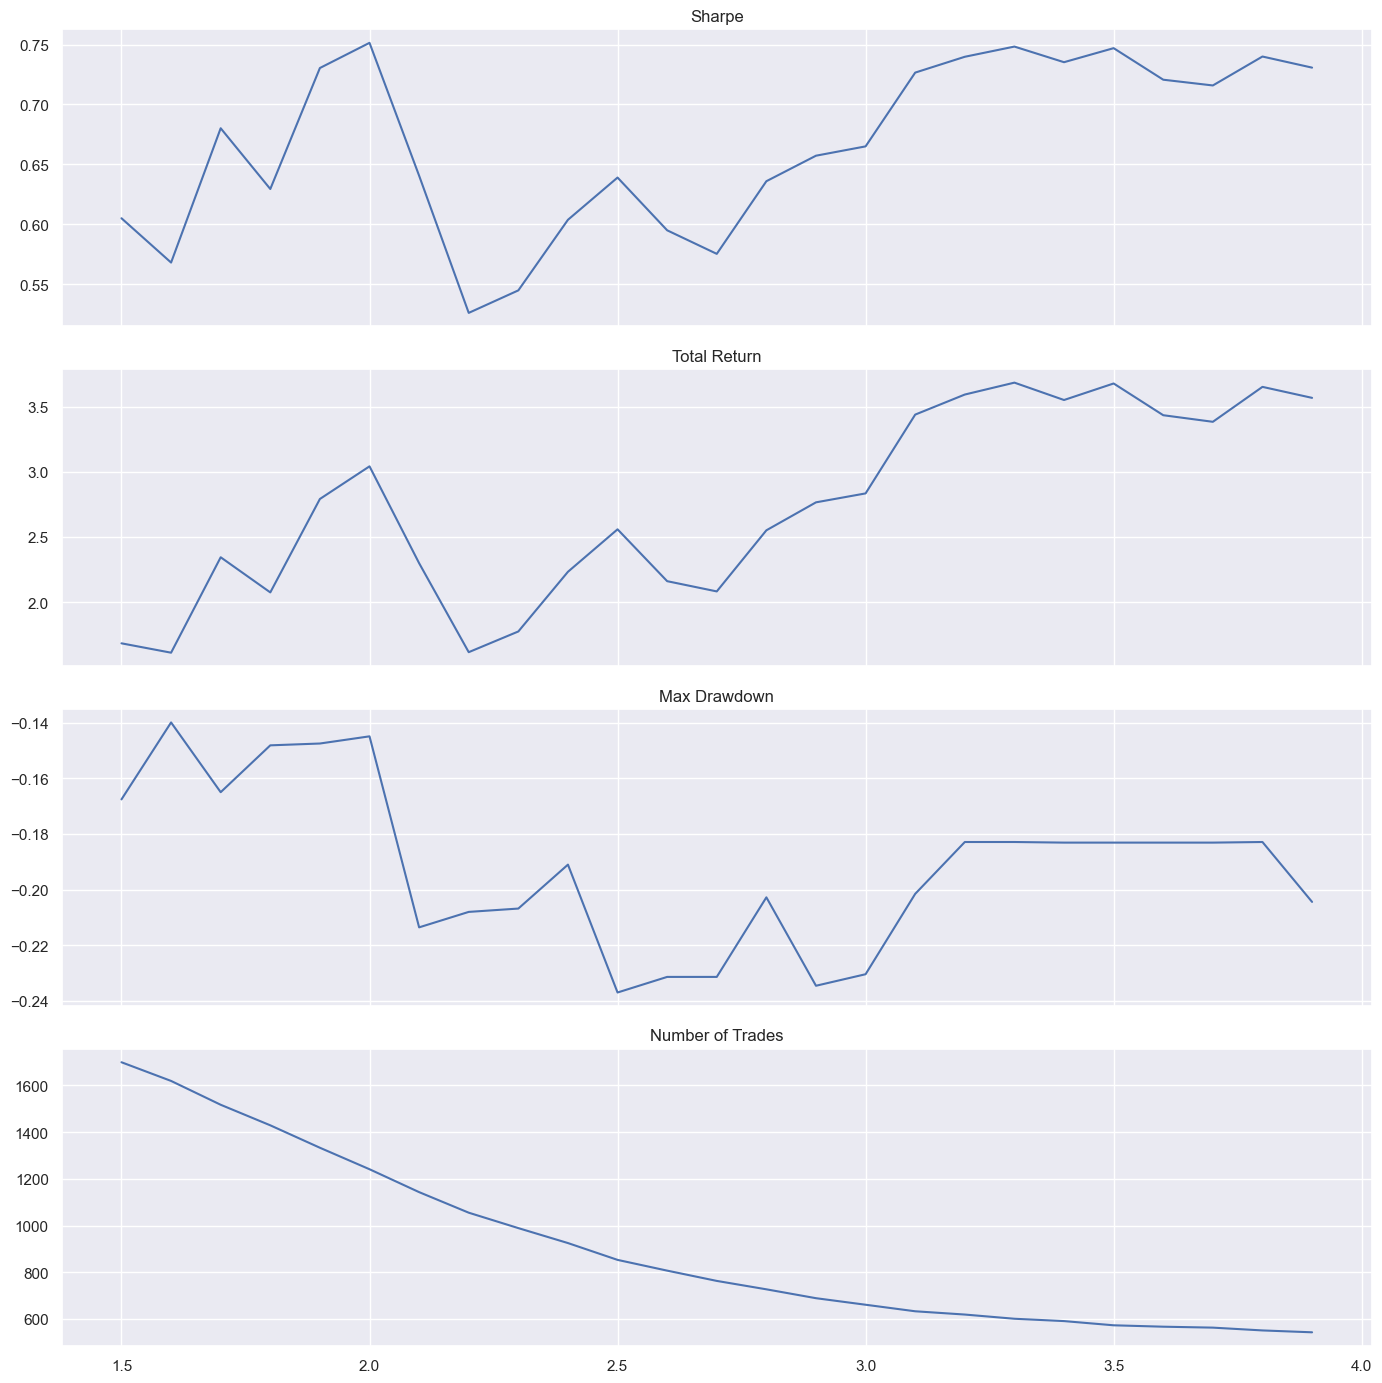

In [16]:
results_df = e_stop_results_df.sort_values("e_stop", ascending=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(results_df["e_stop"], results_df["sharpe"], label="Sharpe")
axes[0].set_title("Sharpe")

axes[1].plot(results_df["e_stop"], results_df["total_return"], label="Total Return")
axes[1].set_title("Total Return")

axes[2].plot(results_df["e_stop"], results_df["max_drawdown"], label="Max Drawdown")
axes[2].set_title("Max Drawdown")

axes[3].plot(results_df["e_stop"], results_df["num_trades"], label="Number of Trades")
axes[3].set_title("Number of Trades")

plt.tight_layout()
plt.show()

Set the e_stop variable to 3.3

Now we hyperparameter tune for 2 variables (z_full & p) for the following function that gives us our trading position depending on our trading signal:

$$
f(z)=
\begin{cases}
0, & |z| < 1.4, \\[6pt]
100\left(\dfrac{|z|-1.4}{z_{\text{full}}-1.4}\right)^p, & 1.4 \le |z| < z_{\text{full}}, \\[10pt]
100, & |z| \ge z_{\text{full}}.
\end{cases}
$$

In [24]:
def position_size_power(
        z,
        full_size_z,
        p,
        entry_z=1.4,
        max_position_pct=100.0
):
    """
    Converts abs(z) into a smooth position size.

    p < 1  = aggressive early scaling
    p = 1  = linear scaling
    p > 1  = slower early scaling
    """

    abs_z = abs(z)

    if abs_z < entry_z:
        return 0.0

    if abs_z >= full_size_z:
        return max_position_pct

    scaled_signal = (abs_z - entry_z) / (full_size_z - entry_z)

    return max_position_pct * (scaled_signal ** p)

In [25]:
def target_position_power_ratchet(
        today_z,
        previous_position,
        full_size_z,
        p,
        entry_z=1.4,
        exit_z=0.9,
        e_stop=3.3,
        max_position_pct=100.0
):
    """
    Ratcheting position rule.

    Positive position = long spread = long PEP, short KO.
    Negative position = short spread = short PEP, long KO.

    Main rule:
        - enter when abs(z) >= entry_z
        - scale UP if signal strengthens
        - do NOT scale down if signal weakens
        - exit only if abs(z) <= exit_z
        - emergency exit if abs(z) >= e_stop
    """

    abs_z = abs(today_z)

    # --------------------------------------------------
    # 1. Emergency stop
    # --------------------------------------------------
    if abs_z >= e_stop:
        return 0.0

    # --------------------------------------------------
    # 2. Normal exit
    # --------------------------------------------------
    if previous_position != 0:
        if abs_z <= exit_z:
            return 0.0

    # --------------------------------------------------
    # 3. If flat, only enter after entry_z
    # --------------------------------------------------
    if previous_position == 0:
        if abs_z < entry_z:
            return 0.0

        new_size = position_size_power(
            z=today_z,
            full_size_z=full_size_z,
            p=p,
            entry_z=entry_z,
            max_position_pct=max_position_pct
        )

        if today_z > 0:
            return -new_size  # short spread: short PEP, long KO

        if today_z < 0:
            return new_size  # long spread: long PEP, short KO

        return 0.0

    # --------------------------------------------------
    # 4. If currently long spread
    # --------------------------------------------------
    if previous_position > 0:

        # If signal flips sign, exit
        if today_z > 0:
            return 0.0

        new_size = position_size_power(
            z=today_z,
            full_size_z=full_size_z,
            p=p,
            entry_z=entry_z,
            max_position_pct=max_position_pct
        )

        # Ratchet: only increase size, never decrease
        size = max(abs(previous_position), new_size)

        return size

    # --------------------------------------------------
    # 5. If currently short spread
    # --------------------------------------------------
    if previous_position < 0:

        # If signal flips sign, exit
        if today_z < 0:
            return 0.0

        new_size = position_size_power(
            z=today_z,
            full_size_z=full_size_z,
            p=p,
            entry_z=entry_z,
            max_position_pct=max_position_pct
        )

        # Ratchet: only increase size, never decrease
        size = max(abs(previous_position), new_size)

        return -size

    return 0.0

In [26]:
def dollar_positions_from_percent(
        target_position_pct,
        beta,
        current_equity
):
    """
    Converts signed target spread position into PEP/KO dollar positions.

    Positive position = long PEP, short KO.
    Negative position = short PEP, long KO.
    """

    if target_position_pct == 0 or np.isnan(beta):
        return 0.0, 0.0

    gross_exposure = current_equity * abs(target_position_pct) / 100.0

    pep_weight = 1.0 / (1.0 + abs(beta))
    ko_weight = abs(beta) / (1.0 + abs(beta))

    pep_dollars = gross_exposure * pep_weight
    ko_dollars = gross_exposure * ko_weight

    if target_position_pct > 0:
        # Long spread: long PEP, short KO
        return pep_dollars, -ko_dollars

    else:
        # Short spread: short PEP, long KO
        return -pep_dollars, ko_dollars

In [27]:
def trade_dollars_from_targets(
        target_pep_dollars,
        target_ko_dollars,
        previous_pep_dollars,
        previous_ko_dollars
):
    """
    Calculates how much PEP and KO exposure to add/remove today.
    """

    pep_trade_dollars = target_pep_dollars - previous_pep_dollars
    ko_trade_dollars = target_ko_dollars - previous_ko_dollars

    return pep_trade_dollars, ko_trade_dollars

In [28]:
def run_backtest_for_power_sizing(
        original_df,
        full_size_z,
        p,
        lookback=78,
        entry_z=1.4,
        exit_z=0.9,
        e_stop=3.3,
        starting_equity=100000,
        max_position_pct=100.0,
        min_rebalance_change=5.0
):
    """
    Backtests KO/PEP pairs strategy using Function 1: power-ramp sizing.

    Tuned parameters:
        full_size_z
        p
    """

    if full_size_z <= entry_z:
        raise ValueError("full_size_z must be greater than entry_z.")

    if full_size_z >= e_stop:
        raise ValueError("full_size_z should be less than e_stop.")

    if p <= 0:
        raise ValueError("p must be positive.")

    df = original_df.copy()

    # --------------------------------------------------
    # 1. Estimate rolling beta, spread, and z-score
    # --------------------------------------------------
    df["beta"] = np.nan
    df["spread"] = np.nan
    df["zscore"] = np.nan

    for i in range(lookback, len(df)):
        train = df.iloc[i - lookback:i]

        x = train["log_KO"].values
        y = train["log_PEP"].values

        beta = np.polyfit(x, y, 1)[0]
        df.loc[i, "beta"] = beta

        train_spread = train["log_PEP"] - beta * train["log_KO"]
        mu = train_spread.mean()
        sigma = train_spread.std()

        current_spread = df.loc[i, "log_PEP"] - beta * df.loc[i, "log_KO"]

        df.loc[i, "spread"] = current_spread
        df.loc[i, "zscore"] = 0.0 if sigma == 0 else (current_spread - mu) / sigma

    # --------------------------------------------------
    # 2. Backtest dollar positions
    # --------------------------------------------------
    df["equity"] = np.nan
    df["daily_pnl"] = 0.0
    df["strategy_ret"] = 0.0

    df["target_position_pct"] = 0.0
    df["pep_dollars"] = 0.0
    df["ko_dollars"] = 0.0

    df["pep_trade_dollars"] = 0.0
    df["ko_trade_dollars"] = 0.0

    current_equity = starting_equity

    previous_position_pct = 0.0
    previous_pep_dollars = 0.0
    previous_ko_dollars = 0.0

    for i in range(lookback, len(df)):

        # --------------------------------------------------
        # A. Realize today's PnL from yesterday's holdings
        # --------------------------------------------------
        if i > lookback:
            pep_ret = df.loc[i, "PEP_ret"]
            ko_ret = df.loc[i, "KO_ret"]

            if pd.isna(pep_ret):
                pep_ret = 0.0
            if pd.isna(ko_ret):
                ko_ret = 0.0

            pnl = previous_pep_dollars * pep_ret + previous_ko_dollars * ko_ret

            old_equity = current_equity
            current_equity += pnl

            df.loc[i, "daily_pnl"] = pnl
            df.loc[i, "strategy_ret"] = 0.0 if old_equity == 0 else pnl / old_equity

        # --------------------------------------------------
        # B. Generate today's target percent position
        # --------------------------------------------------
        today_z = df.loc[i, "zscore"]

        target_position_pct = target_position_power(
            today_z=today_z,
            previous_position=previous_position_pct,
            full_size_z=full_size_z,
            p=p,
            entry_z=entry_z,
            exit_z=exit_z,
            e_stop=e_stop,
            max_position_pct=max_position_pct,
            min_rebalance_change=min_rebalance_change
        )

        # --------------------------------------------------
        # C. Convert target percent into target dollar positions
        # --------------------------------------------------
        beta = df.loc[i, "beta"]

        target_pep_dollars, target_ko_dollars = dollar_positions_from_percent(
            target_position_pct=target_position_pct,
            beta=beta,
            current_equity=current_equity
        )

        # --------------------------------------------------
        # D. Calculate trades
        # --------------------------------------------------
        pep_trade_dollars, ko_trade_dollars = trade_dollars_from_targets(
            target_pep_dollars=target_pep_dollars,
            target_ko_dollars=target_ko_dollars,
            previous_pep_dollars=previous_pep_dollars,
            previous_ko_dollars=previous_ko_dollars
        )

        # --------------------------------------------------
        # E. Store values
        # --------------------------------------------------
        df.loc[i, "equity"] = current_equity
        df.loc[i, "target_position_pct"] = target_position_pct

        df.loc[i, "pep_dollars"] = target_pep_dollars
        df.loc[i, "ko_dollars"] = target_ko_dollars

        df.loc[i, "pep_trade_dollars"] = pep_trade_dollars
        df.loc[i, "ko_trade_dollars"] = ko_trade_dollars

        # --------------------------------------------------
        # F. Update previous holdings
        # --------------------------------------------------
        previous_position_pct = target_position_pct
        previous_pep_dollars = target_pep_dollars
        previous_ko_dollars = target_ko_dollars

    # Fill early equity values
    df["equity"] = df["equity"].ffill().fillna(starting_equity)
    df["equity_curve"] = df["equity"] / starting_equity

    # --------------------------------------------------
    # 3. Metrics
    # --------------------------------------------------
    mean_ret = df["strategy_ret"].mean()
    std_ret = df["strategy_ret"].std()

    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret
    total_return = df["equity"].iloc[-1] / starting_equity - 1

    rolling_max = df["equity"].cummax()
    drawdown = df["equity"] / rolling_max - 1
    max_drawdown = drawdown.min()

    num_trades = (df["target_position_pct"].diff().abs() > 0).sum()

    total_turnover = (
            df["pep_trade_dollars"].abs() + df["ko_trade_dollars"].abs()
    ).sum()

    return {
        "full_size_z": full_size_z,
        "p": p,
        "lookback": lookback,
        "entry_z": entry_z,
        "exit_z": exit_z,
        "e_stop": e_stop,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "num_trades": num_trades,
        "final_equity": df["equity"].iloc[-1],
        "total_turnover": total_turnover,
        "backtest_df": df
    }

In [29]:
results = []

full_size_z_values = np.round(np.arange(1.5, 3.3, 0.1), 2)
p_values = np.round(np.arange(0.1, 1.1, 0.1), 2)

for full_size_z in full_size_z_values:
    for p in p_values:

        if full_size_z <= 1.4:
            continue

        if full_size_z >= 3.3:
            continue

        result = run_backtest_for_power_sizing(
            training_set,
            full_size_z=full_size_z,
            p=p,
            lookback=78,
            entry_z=1.4,
            exit_z=0.9,
            e_stop=3.3,
            starting_equity=100_000,
            max_position_pct=100.0,
            min_rebalance_change=5.0
        )

        results.append({
            "full_size_z": result["full_size_z"],
            "p": result["p"],
            "sharpe": result["sharpe"],
            "total_return": result["total_return"],
            "max_drawdown": result["max_drawdown"],
            "num_trades": result["num_trades"],
            "final_equity": result["final_equity"],
            "total_turnover": result["total_turnover"]
        })

power_results_df = pd.DataFrame(results)
power_results_df = power_results_df.sort_values("sharpe", ascending=False)

power_results_df.head(20)

,full_size_z,p,sharpe,total_return,max_drawdown,num_trades,final_equity,total_turnover
152,3.0,0.3,0.592843,0.723036,-0.141021,1538,172303.575606,8.696907e+07
142,2.9,0.3,0.592459,0.736459,-0.143447,1534,173645.922069,8.886318e+07
92,2.4,0.3,0.590969,0.819389,-0.155973,1478,181938.918864,1.001543e+08
151,3.0,0.2,0.590345,0.798643,-0.146779,1440,179864.277012,9.697686e+07
162,3.1,0.3,0.590185,0.704119,-0.138621,1530,170411.943684,8.483522e+07
161,3.1,0.2,0.589872,0.785980,-0.145112,1444,178597.956626,9.539044e+07
172,3.2,0.3,0.589841,0.689295,-0.136394,1530,168929.469723,8.296850e+07
102,2.5,0.3,0.589810,0.798512,-0.152190,1493,179851.225431,9.768320e+07
121,2.7,0.2,0.589307,0.832636,-0.150952,1431,183263.553232,1.018214e+08
132,2.8,0.3,0.589292,0.746209,-0.145877,1528,174620.869696,9.071679e+07


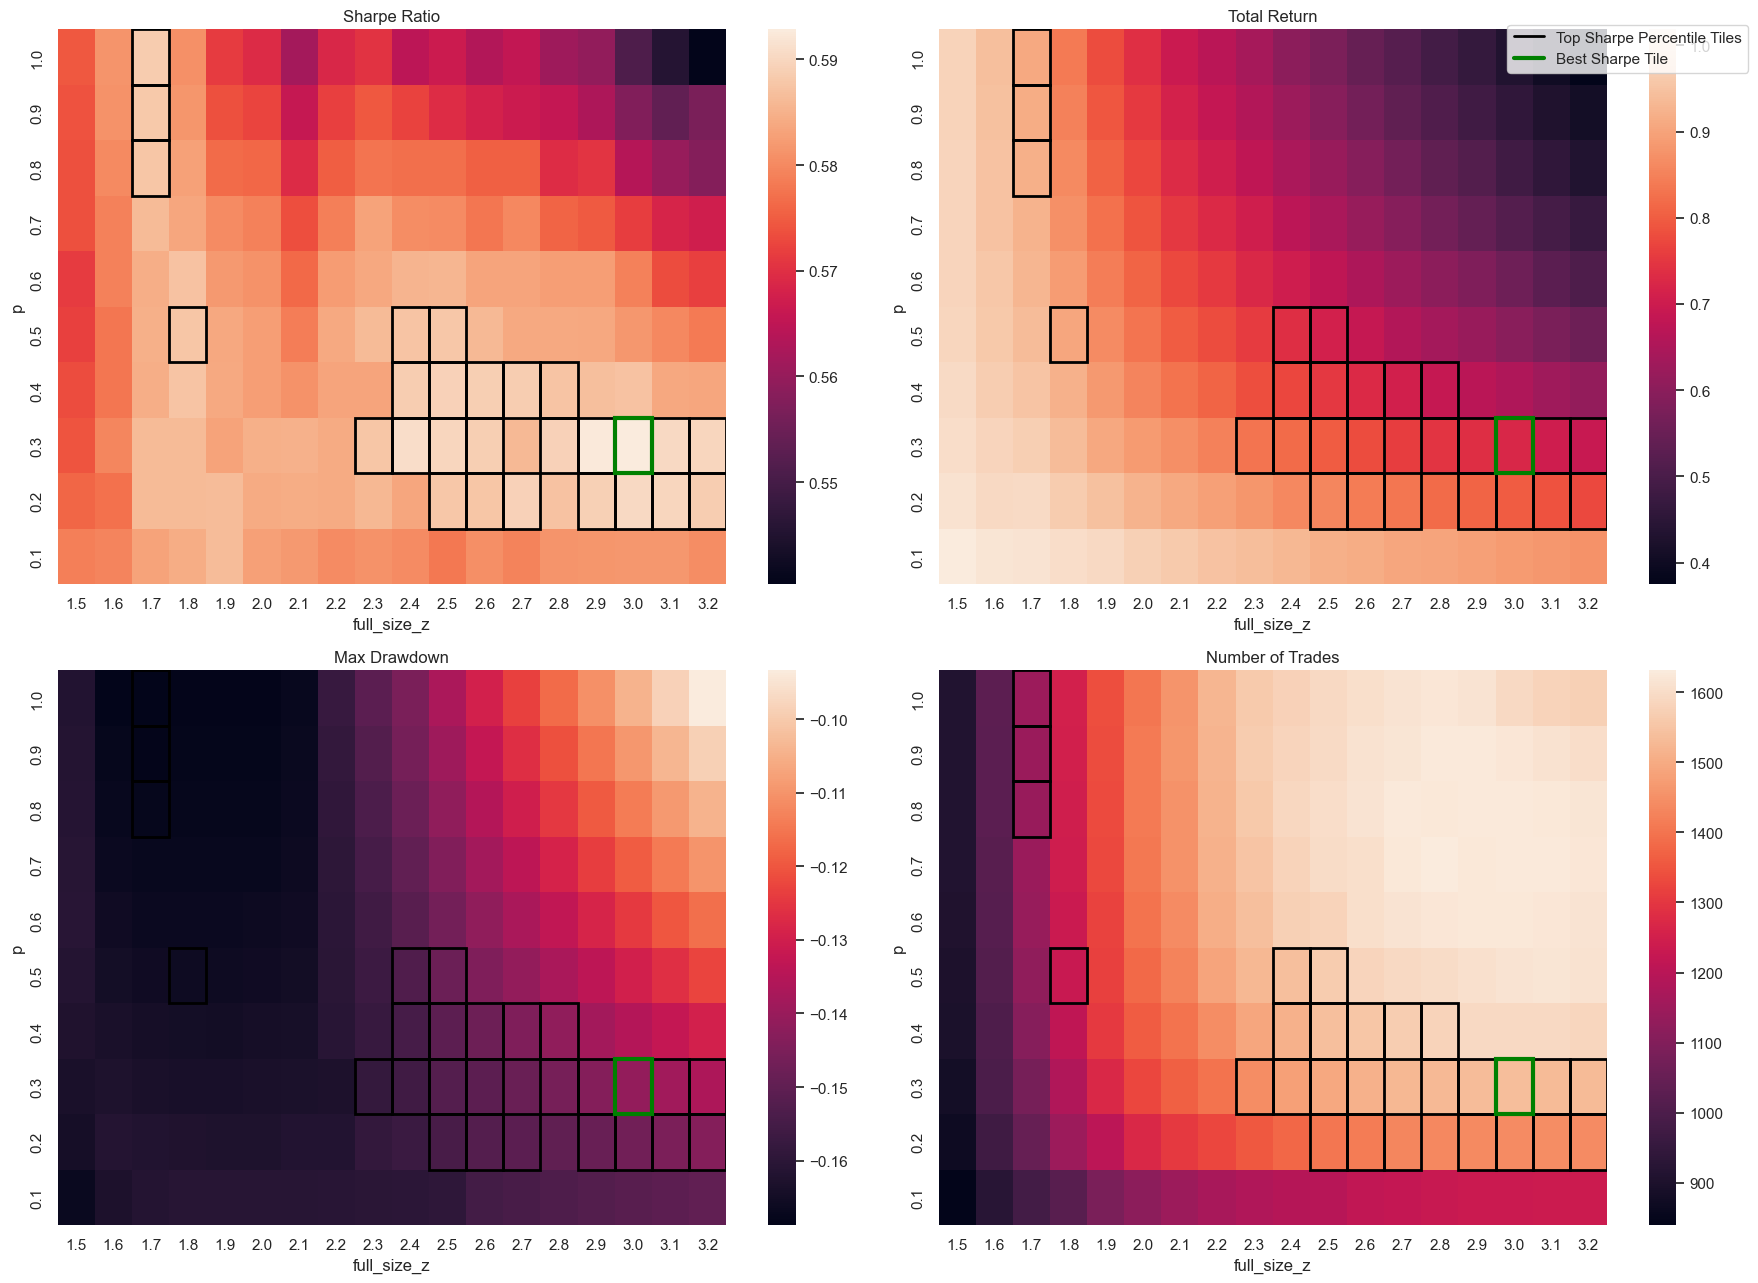

full_size_z = 3.0
p = 0.3


In [34]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

sns.set_theme(style="white")

plot_df = power_results_df.copy()

sharpe_pivot = plot_df.pivot(index="p", columns="full_size_z", values="sharpe")
return_pivot = plot_df.pivot(index="p", columns="full_size_z", values="total_return")
drawdown_pivot = plot_df.pivot(index="p", columns="full_size_z", values="max_drawdown")
trades_pivot = plot_df.pivot(index="p", columns="full_size_z", values="num_trades")

sharpe_pivot = sharpe_pivot.sort_index(ascending=False)
return_pivot = return_pivot.sort_index(ascending=False)
drawdown_pivot = drawdown_pivot.sort_index(ascending=False)
trades_pivot = trades_pivot.sort_index(ascending=False)

best_sharpe_p, best_sharpe_full_size_z = sharpe_pivot.stack().idxmax()
best_sharpe_row = sharpe_pivot.index.get_loc(best_sharpe_p)
best_sharpe_col = sharpe_pivot.columns.get_loc(best_sharpe_full_size_z)

threshold = sharpe_pivot.stack().quantile(0.85)
eligible_mask = (sharpe_pivot >= threshold) & (~sharpe_pivot.isna())

top_percentile_cells = []
for r in range(eligible_mask.shape[0]):
    for c in range(eligible_mask.shape[1]):
        if eligible_mask.iat[r, c]:
            top_percentile_cells.append((r, c))


def add_highlights(ax, best_row, best_col, top_percentile_cells):
    for r, c in top_percentile_cells:
        rect = Rectangle((c, r), 1, 1, fill=False, edgecolor="black", linewidth=2)
        ax.add_patch(rect)

    rect = Rectangle((best_col, best_row), 1, 1, fill=False, edgecolor="green", linewidth=3)
    ax.add_patch(rect)


fig, axes = plt.subplots(2, 2, figsize=(18, 13))

sns.heatmap(sharpe_pivot, annot=False, ax=axes[0, 0], cbar=True)
axes[0, 0].set_title("Sharpe Ratio")
axes[0, 0].set_xlabel("full_size_z")
axes[0, 0].set_ylabel("p")
add_highlights(axes[0, 0], best_sharpe_row, best_sharpe_col, top_percentile_cells)

sns.heatmap(return_pivot, annot=False, ax=axes[0, 1], cbar=True)
axes[0, 1].set_title("Total Return")
axes[0, 1].set_xlabel("full_size_z")
axes[0, 1].set_ylabel("p")
add_highlights(axes[0, 1], best_sharpe_row, best_sharpe_col, top_percentile_cells)

sns.heatmap(drawdown_pivot, annot=False, ax=axes[1, 0], cbar=True)
axes[1, 0].set_title("Max Drawdown")
axes[1, 0].set_xlabel("full_size_z")
axes[1, 0].set_ylabel("p")
add_highlights(axes[1, 0], best_sharpe_row, best_sharpe_col, top_percentile_cells)

sns.heatmap(trades_pivot, annot=False, ax=axes[1, 1], cbar=True)
axes[1, 1].set_title("Number of Trades")
axes[1, 1].set_xlabel("full_size_z")
axes[1, 1].set_ylabel("p")
add_highlights(axes[1, 1], best_sharpe_row, best_sharpe_col, top_percentile_cells)

# Legend
legend_handles = [
    Line2D([0], [0], color="black", lw=2, label="Top Sharpe Percentile Tiles"),
    Line2D([0], [0], color="green", lw=3, label="Best Sharpe Tile")
]
fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.show()

print("full_size_z =", best_sharpe_full_size_z)
print("p =", best_sharpe_p)

Set full_size_z to 3.0 and p to 0.3